In [1]:
import random
import math
import numpy as np
import copy
import matplotlib.pyplot as plt

def print_matrix(M):
    for row in M:
        row_rounded = [round(x, 2) for x in row]
        row_no_negative_zeros = [0.0 if math.isclose(x, 0.0) else x for x in row_rounded]
        print(" ".join(f"{x:.2f}" for x in row_no_negative_zeros))
    print()


def divide_row(row, k, M):
    n = len(M)
    for j in range(n):
        M[row][j] /= k


def swap_rows(row1, row2, M):
    n = len(M)
    for j in range(n):
        M[row1][j], M[row2][j] = M[row2][j], M[row1][j]


def add_scaled_row_to_another(row1, row2, k, M):
    n = len(M)
    for j in range(n):
        M[row2][j] += M[row1][j] * k


def gauss_elimination(M, pivoting = True, normalize = True):
    n = len(M)

    for j in range(n): 
        if pivoting:
            maxi, pivot_idx = 0.0, 0
            for i in range(j, n):
                if abs(M[i][j]) > maxi :
                    maxi, pivot_idx = abs(M[i][j]), i
            if pivot_idx != j: # we need to swap
                swap_rows(j, pivot_idx, M)
        if normalize:
            divide_row(j, M[j][j], M) # we want our row to have 1.0 as the element on the diagonal

        for k in range(j + 1, n):
            assert not np.isclose(M[j][j], 0)
            add_scaled_row_to_another(j, k, -M[k][j]/M[j][j], M) 


def inverse_matrix(M):
    n = len(M)
    M_res = [[0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        M_res[i][i] = 1
    
    for j in range(n):
        maxi, pivot_idx = 0.0, 0 
        for i in range(j, n):
            if abs(M[i][j]) > maxi :
                maxi, pivot_idx = abs(M[i][j]), i 

        if pivot_idx != j:
            swap_rows(j, pivot_idx, M)
            swap_rows(j, pivot_idx, M_res)

        div = M[j][j]
        divide_row(j, div, M) 
        divide_row(j, div, M_res)

        for k in range(n):
            if k != j:
                scalar = -M[k][j]
                add_scaled_row_to_another(j, k, scalar, M) 
                add_scaled_row_to_another(j, k, scalar, M_res)

    return M_res



n = 6
M1 = [[random.randint(0, 15) for _ in range(n)] for _ in range(n)]
M2 = copy.deepcopy(M1)


print()
print_matrix(M1)
print("\nAFTER GAUSS ELIMINATION:\n")
gauss_elimination(M1)
print_matrix(M1)


if np.linalg.det(np.array(M2)) != 0:
    print("\nINVERSE MATRIX\n")
    print_matrix(inverse_matrix(M2))


9.00 7.00 7.00 14.00 15.00 0.00
10.00 1.00 8.00 14.00 10.00 2.00
10.00 1.00 11.00 12.00 12.00 12.00
13.00 10.00 4.00 3.00 15.00 0.00
6.00 5.00 12.00 2.00 4.00 0.00
12.00 8.00 7.00 4.00 1.00 8.00


AFTER GAUSS ELIMINATION:

1.00 0.77 0.31 0.23 1.15 0.00
0.00 1.00 -0.74 -1.75 0.23 -0.30
0.00 0.00 1.00 0.12 -0.29 0.01
0.00 0.00 0.00 1.00 0.51 0.00
0.00 0.00 0.00 0.00 1.00 -0.68
0.00 0.00 0.00 0.00 0.00 1.00


INVERSE MATRIX

-0.13 0.15 -0.04 0.07 -0.02 0.03
0.15 -0.14 -0.02 -0.04 0.00 0.07
-0.01 -0.01 0.02 -0.02 0.10 -0.02
0.08 0.02 -0.03 -0.07 -0.04 0.04
0.00 -0.04 0.05 0.05 0.00 -0.07
0.02 -0.09 0.08 -0.02 -0.04 0.03



In [42]:
def gauss_numpy(A, pivoting = True, normalize = True, b = None):
    n = len(A)
    A = np.array(A, dtype=np.float32)
    for i in range(n):
        if pivoting or np.isclose(A[i, i], 0.0):
            if pivoting:
                pivot_idx = i + np.argmax(np.abs(A[i:, i]))
            else:
                try:
                    pivot_idx = i + np.where(~np.isclose(np.abs(A[i:, i]), 0.0))[0][0]
                except IndexError:
                    print("No nonzero found in column\n", A[i:, i])
            
            if pivot_idx != i:
                A[[i, pivot_idx]] = A[[pivot_idx, i]]
                if b is not None:
                    b[i], b[pivot_idx] = b[pivot_idx], b[i]

        assert not np.isclose(A[i, i], 0.0)

        if normalize:
            A[i, :] /= A[i, i]
            if b is not None:
                b[i] /= A[i, i]

        for j in range(i+1, n):
            factor = A[j][i]/A[i, i]
            A[j, :] -= factor * A[i, :]
            if b is not None:
                b[j] -= factor * b[i]
    return A, b


def back_substitution(U:np.ndarray, b:np.ndarray):
    x = np.zeros_like(b)
    nn = U.shape[0]
    for i in range(nn-1, -1, -1):
        sum = 0
        for j in range(i+1, nn):
            sum += x[j] * U[i, j]
        print("sum:", sum)
        x[i] = b[i] - sum
    print(x)
    return x


def lu_factorization(A, pivoting = True):
    n = len(A)
    P = [i for i in range(n)]
    A = np.array(A, dtype=np.float32)
    L, U = np.array([[0.0 for _ in range(n)] for _ in range(n)]), np.copy(A)
    for i in range(n):
        L[i, i] = 1.0
    for i in range(n):
        
        if pivoting or np.isclose(U[i, i], 0.0):
            if pivoting:
                pivot_idx = i + np.argmax(np.abs(U[i:, i]))
            else:
                pivot_idx = i + np.where(~np.isclose(np.abs(U[i:, i]), 0.0))[0][0]
        
            if pivot_idx != i:
                U[[i, pivot_idx]] = U[[pivot_idx, i]]
                L[[i, pivot_idx], :i] = L[[pivot_idx, i], :i]
                P[i], P[pivot_idx] = P[pivot_idx], P[i]

            assert not np.isclose(U[i, i], 0.0)

        for j in range(i+1, n):
            factor = U[j][i]/U[i, i]
            U[j, :] -= factor * U[i, :]
            L[j, i] = factor

    P = np.array(P)
    P_res = np.zeros((P.size, P.max() + 1))
    P_res[np.arange(P.size), P] = 1
    return P_res, L , U


def assert_is_close(P, L, U, A):
    A1 = np.transpose(P) @ L @ U
    diff = np.abs(A1 - A)
    return np.allclose(P @ A, L @ U), diff


def assert_l_matrix(L, tol):
    identity = np.eye(L.shape[0])
    L_tr = np.triu(L) # eliminates nonzero elements of upper diagonal part
    assert np.allclose(L_tr - identity, np.zeros_like(L), atol = tol) # checks ones on diagonal


def assert_u_matrix(U, tol, has_ones = False):
    U_tr = np.tril(U, (-1 if not has_ones else 0) )
    if has_ones:
        U_tr -= np.eye(U.shape[0])
    assert np.allclose(U_tr, 0, atol=tol)


In [ ]:
NUM_TRIALS = 10000
n = 5

pivot_diff = []
with_error, without_error = 0, 0
for i in range(NUM_TRIALS):
    if i % (NUM_TRIALS//50) == 0:
        print(i, end = ' ')
    M3 = [[random.random() * 10 for _ in range(n)] for _ in range(n)]
    M3 = np.array(M3)
    P2, L2, U2 = lu_factorization(M3)
    P3, L3, U3 = lu_factorization(M3, False)

    for j, (Lj, Uj, tol) in enumerate([[L2, U2, 2e-6], [L3, U3, 5e-3]]):
        try:
            assert_l_matrix(Lj, tol)
            assert_u_matrix(Uj, tol)
        except Exception as e:
            if j == 0:
                with_error += 1
            else:
                without_error += 1

    
    pivot, no_pivot = np.max(np.abs((P2 @ M3 - L2 @ U2))), np.max(np.abs((P3 @ M3 - L3 @ U3)))
    diff_i = no_pivot/pivot
    pivot_diff.append([no_pivot, pivot, diff_i])
    

pivot_diff = np.array(pivot_diff)

0 200 400 600 800 1000 1200 1400 1600 1800 2000 2200 2400 2600 2800 3000 3200 3400 3600 3800 4000 4200 4400 4600 4800 5000 5200 5400 5600 5800 6000 6200 6400 6600 6800 7000 7200 7400 7600 7800 8000 8200 8400 8600 8800 9000 9200 9400 9600 9800 

In [4]:
print(f"Outside the tolerance: pivot = {with_error}/{NUM_TRIALS}, no_pivot = {without_error}/{NUM_TRIALS}")

Outside the tolerance: pivot = 978/10000, no_pivot = 1130/10000


Lims: (0, 257.13)
Median no pivot: 0.0001624584592576639
Median with pivot 3.7678162116971947e-06
Max difference: 361990


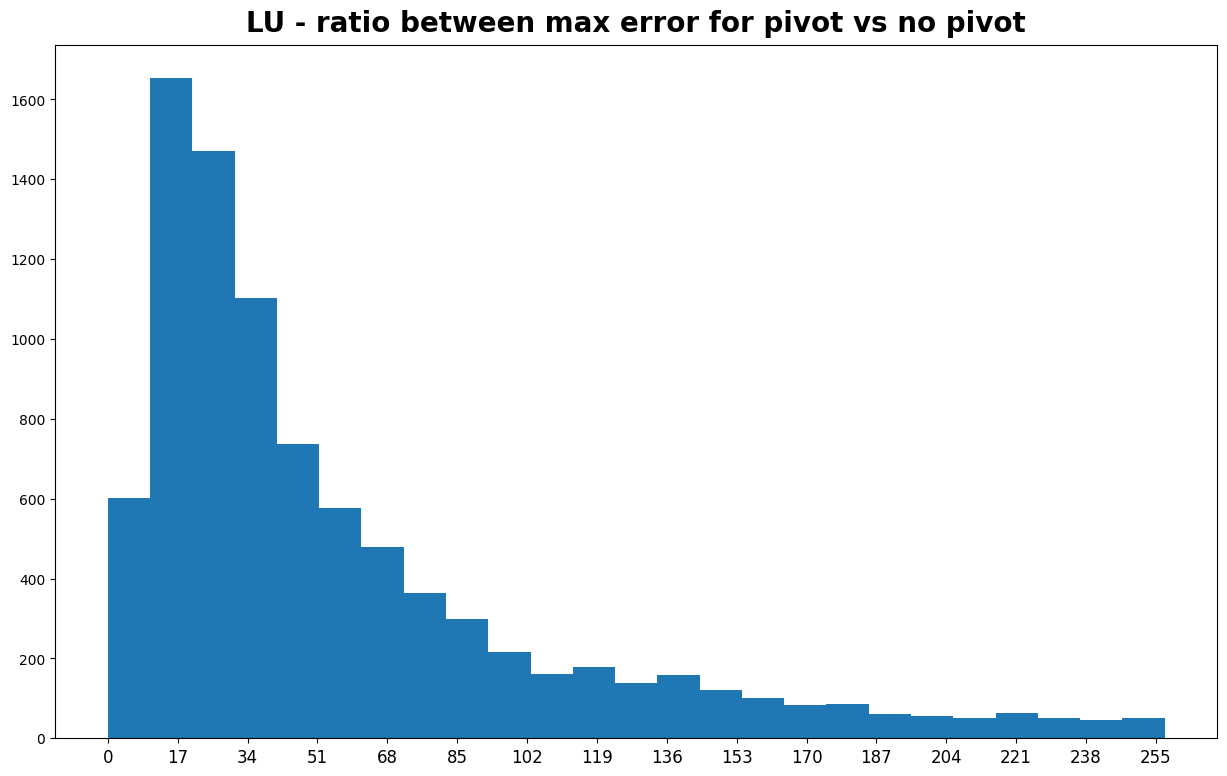

In [5]:
lims = [0, np.percentile(pivot_diff[:, 2], 89)]
k = 25
s = 15

print(f"Lims: ({lims[0]}, {round(lims[1], 2)})")

plt.figure(figsize=(15, 9))
plt.hist(pivot_diff[:, 2], bins=[lims[1]/k * i for i in range(k+1)])
plt.xticks([round(lims[1]/s) * i for i in range(s+1)], fontsize = 12)

plt.title("LU - ratio between max error for pivot vs no pivot", fontsize=20, fontweight='bold', pad=10 )

print("Median no pivot:", np.median(pivot_diff[:, 0]))
print("Median with pivot", np.median(pivot_diff[:, 1]))

idx_max = np.argmax(pivot_diff[:, 2])

print("Max difference:", round(np.max(pivot_diff[:, 2])))

In [ ]:
NUM_TRIALS = 1000
gauss_with, gauss_without = 0, 0
gauss_pivot_diff = []
n = 5
for i in range(NUM_TRIALS):

    A = np.array([[random.random() * 15 for _ in range(n)] for _ in range(n)])
    x = np.array([random.random() * 100 for _ in range(n)])
    b = np.dot(A, x)

    U1, b1 = gauss_numpy(M3, pivoting=False, b = b)
    x_without = back_substitution(U1, b1)
    no_pivot = np.max(np.abs(x_without - x))
    if i % (NUM_TRIALS//50) == 0:
        if i == 100:
            print(x)
            print("\n\n")
            print(x_without)
        print(i, end = ' ')


    U2 = gauss_numpy(M3, pivoting=True, b = b)
    x_with = back_substitution(U2, b)
    pivot = np.max(np.abs(x_with - x))

    gauss_pivot_diff.append([no_pivot, pivot, no_pivot/pivot])

    U2 = gauss_numpy(M3, pivoting=True)
    

0 20 40 60 80 [93.720995   52.27157942 43.49179521 21.80190646 31.7420828 ]



[ 2563.19235375  6726.94593988  -551.99779247 -3327.36294272
  2400.07556038]
100 120 140 160 180 200 220 240 260 280 300 320 340 360 380 400 420 440 460 480 500 520 540 560 580 600 620 640 660 680 700 720 740 760 780 800 820 840 860 880 900 920 940 960 980 

In [21]:
print(f"Outside the tolerance: pivot = {gauss_with}/{NUM_TRIALS}, no_pivot = {gauss_without}/{NUM_TRIALS}")
gauss_pivot_diff = np.array(gauss_pivot_diff)


Outside the tolerance: pivot = 0/10000, no_pivot = 0/10000


(array([  37.,  386., 1514., 2801., 2928., 1581.,  587.,  133.,   28.,
           5.]),
 array([0.24144442, 0.26489586, 0.28834729, 0.31179872, 0.33525016,
        0.35870159, 0.38215303, 0.40560446, 0.42905589, 0.45250733,
        0.47595876]),
 <BarContainer object of 10 artists>)

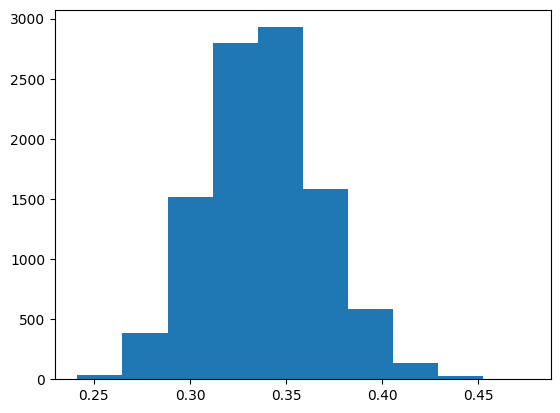

In [22]:
plt.hist(gauss_pivot_diff[:, 2])

In [44]:
A = np.array([[random.random() * 20 for _ in range(5)] for _ in range(5)])
x = np.array([random.random() * 50 for _ in range(n)])
b = np.dot(A, x)
U2, b2 = gauss_numpy(A, pivoting = True, b = b)
print(b2)
x2 = back_substitution(U2, b2)
print(x)
print(x2)


[   742.43335873  -9207.0182285  -55034.64301639  28457.48612581
 -45302.68364118]
sum: 0
sum: 6692.513826388305
sum: 11352.319468239937
sum: -12681.009314172685
sum: -47692.81130557219
[ 48435.24466431   3473.99108567 -66386.96248463  21764.97229942
 -45302.68364118]
[ 0.62701539 15.0408334  21.76668866 21.54190168 20.16996336]
[ 48435.24466431   3473.99108567 -66386.96248463  21764.97229942
 -45302.68364118]
